In [56]:
import pandas as pd

customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
transactions = pd.read_csv('transactions.csv')

customers_head = customers.head()
products_head = products.head()
transactions_head = transactions.head()

(customers_head, products_head, transactions_head)


(  client_id sex  birth
 0    c_4410   f   1967
 1    c_7839   f   1975
 2    c_1699   f   1984
 3    c_5961   f   1962
 4    c_5320   m   1943,
   id_prod  price  categ
 0  0_1421  19.99      0
 1  0_1368   5.13      0
 2   0_731  17.99      0
 3   1_587   4.99      1
 4  0_1507   3.99      0,
   id_prod                        date session_id client_id
 0  0_1483  2021-04-10 18:37:28.723910    s_18746    c_4450
 1   2_226  2022-02-03 01:55:53.276402   s_159142     c_277
 2   1_374  2021-09-23 15:13:46.938559    s_94290    c_4270
 3  0_2186  2021-10-17 03:27:18.783634   s_105936    c_4597
 4  0_1351  2021-07-17 20:34:25.800563    s_63642    c_1242)

In [50]:
transactions_cleaned = transactions[~transactions['date'].str.startswith("test")]

original_count = transactions.shape[0]
cleaned_count = transactions_cleaned.shape[0]
test_transactions_removed = original_count - cleaned_count

(original_count, cleaned_count, test_transactions_removed)


(337016, 336816, 200)

In [51]:
# Identification des produits avec des prix négatifs
negative_price_products = products[products['price'] < 0]

# Correction : Pour l'exemple, nous pourrions les supprimer ou les remplacer par la médiane/la moyenne des prix de leur catégorie.
# Ici, nous choisissons de remplacer par la médiane des prix de la même catégorie pour conserver le produit dans l'analyse.
for index, row in negative_price_products.iterrows():
    category_median = products[products['categ'] == row['categ']]['price'].median()
    products.at[index, 'price'] = category_median

# Vérifier si la correction a été appliquée
remaining_negative_prices = products[products['price'] < 0].shape[0]

# Afficher le nombre de produits qui avaient un prix négatif et la vérification après correction
negative_price_products.shape[0], remaining_negative_prices


(1, 0)

In [52]:
# Vérification de l'unicité des identifiants pour les clients et les produits
unique_clients = customers['client_id'].nunique() == customers.shape[0]
unique_products = products['id_prod'].nunique() == products.shape[0]

# Vérification de l'intégrité référentielle
# Pour les produits : chaque id_prod dans transactions doit exister dans products
product_ids_in_transactions = transactions_cleaned['id_prod'].unique()
missing_product_ids = [pid for pid in product_ids_in_transactions if pid not in products['id_prod'].values]

# Pour les clients : chaque client_id dans transactions doit exister dans customers
client_ids_in_transactions = transactions_cleaned['client_id'].unique()
missing_client_ids = [cid for cid in client_ids_in_transactions if cid not in customers['client_id'].values]

(unique_clients, unique_products, missing_product_ids, missing_client_ids)


(True, True, ['0_2245'], [])

In [53]:
# Exclure les transactions avec des identifiants de produits manquants
transactions_cleaned = transactions_cleaned[~transactions_cleaned['id_prod'].isin(missing_product_ids)]

# Vérifier à nouveau pour s'assurer qu'aucun identifiant de produit manquant n'est présent dans les transactions nettoyées
missing_product_ids_after_exclusion = [pid for pid in transactions_cleaned['id_prod'].unique() if pid not in products['id_prod'].values]

# Nombre de transactions après exclusion
transactions_count_after_exclusion = transactions_cleaned.shape[0]

(missing_product_ids_after_exclusion, transactions_count_after_exclusion)


([], 336713)

In [48]:
# Statistiques descriptives des transactions sans utiliser 'datetime_is_numeric'
desc_transactions_corrected = transactions.describe(include='all')

desc_transactions_corrected


,id_prod,date,session_id,client_id
count,337016,337016,337016,337016
unique,3266,336855,169195,8602
top,1_369,test_2021-03-01 02:30:02.237413,s_0,c_1609
freq,1081,13,200,12855


In [49]:
# Exploration des données : informations de base et recherche de valeurs manquantes

# Informations générales
info_customers = customers.info()
info_products = products.info()
info_transactions = transactions.info()

# Recherche de valeurs manquantes
missing_values_customers = customers.isnull().sum()
missing_values_products = products.isnull().sum()
missing_values_transactions = transactions.isnull().sum()

# Statistiques descriptives pour identifier des anomalies potentielles (ex : prix négatifs)
desc_products = products.describe()
desc_transactions = transactions.describe(include='all', datetime_is_numeric=True)

(missing_values_customers, missing_values_products, missing_values_transactions, desc_products)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337016 entries, 0 to 337015
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     337016 non-null  object
 1   date        337016 non-null  object
 2   session_i

TypeError: NDFrame.describe() got an unexpected keyword argument 'datetime_is_numeric'

<bound method Series.to_string of 0         2021-04-10 18:37:28.723910
1         2022-02-03 01:55:53.276402
2         2021-09-23 15:13:46.938559
3         2021-10-17 03:27:18.783634
4         2021-07-17 20:34:25.800563
                     ...            
337011    2021-05-28 12:35:46.214839
337012    2021-06-19 00:19:23.917703
337013    2021-03-16 17:31:59.442007
337014    2021-10-30 16:50:15.997750
337015    2021-06-26 14:38:19.732946
Name: date, Length: 337016, dtype: object>

In [38]:
# Charger le fichier transactions.csv pour l'examiner
transactions_df = pd.read_csv('transactions.csv')

# Afficher les premières lignes et des informations générales sur le jeu de données
transactions_df_info = transactions_df.info()
transactions_df_head = transactions_df.head()

transactions_df_info, transactions_df_head

# Identification des lignes avec des erreurs de conversion de date
transactions_with_date_errors = transactions_df[transactions_df['date'].isnull()]

# Affichage des quelques lignes pour comprendre la nature des erreurs
transactions_with_date_errors.head()

# Suppression des transactions avec des dates invalides
transactions_df_clean = transactions_df.dropna(subset=['date'])

# Vérification des dimensions après nettoyage
transactions_df_clean.shape

transactions_df_clean


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337016 entries, 0 to 337015
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     337016 non-null  object
 1   date        337016 non-null  object
 2   session_id  337016 non-null  object
 3   client_id   337016 non-null  object
dtypes: object(4)
memory usage: 10.3+ MB


,id_prod,date,session_id,client_id
0,0_1483,2021-04-10 18:37:28.723910,s_18746,c_4450
1,2_226,2022-02-03 01:55:53.276402,s_159142,c_277
2,1_374,2021-09-23 15:13:46.938559,s_94290,c_4270
3,0_2186,2021-10-17 03:27:18.783634,s_105936,c_4597
4,0_1351,2021-07-17 20:34:25.800563,s_63642,c_1242
...,...,...,...,...
337011,1_671,2021-05-28 12:35:46.214839,s_40720,c_3454
337012,0_759,2021-06-19 00:19:23.917703,s_50568,c_6268
337013,0_1256,2021-03-16 17:31:59.442007,s_7219,c_4137
337014,2_227,2021-10-30 16:50:15.997750,s_112349,c_5


In [39]:
transactions

,id_prod,date,session_id,client_id,date_converted
0,0_1483,2021-04-10 18:37:28.723910,s_18746,c_4450,2021-04-10 18:37:28.723910
1,2_226,2022-02-03 01:55:53.276402,s_159142,c_277,2022-02-03 01:55:53.276402
2,1_374,2021-09-23 15:13:46.938559,s_94290,c_4270,2021-09-23 15:13:46.938559
3,0_2186,2021-10-17 03:27:18.783634,s_105936,c_4597,2021-10-17 03:27:18.783634
4,0_1351,2021-07-17 20:34:25.800563,s_63642,c_1242,2021-07-17 20:34:25.800563
...,...,...,...,...,...
337011,1_671,2021-05-28 12:35:46.214839,s_40720,c_3454,2021-05-28 12:35:46.214839
337012,0_759,2021-06-19 00:19:23.917703,s_50568,c_6268,2021-06-19 00:19:23.917703
337013,0_1256,2021-03-16 17:31:59.442007,s_7219,c_4137,2021-03-16 17:31:59.442007
337014,2_227,2021-10-30 16:50:15.997750,s_112349,c_5,2021-10-30 16:50:15.997750


In [34]:
transactions_verif = transactions.drop_duplicates
transactions_verif

<bound method DataFrame.drop_duplicates of        id_prod                        date session_id client_id  \
0       0_1483  2021-04-10 18:37:28.723910    s_18746    c_4450   
1        2_226  2022-02-03 01:55:53.276402   s_159142     c_277   
2        1_374  2021-09-23 15:13:46.938559    s_94290    c_4270   
3       0_2186  2021-10-17 03:27:18.783634   s_105936    c_4597   
4       0_1351  2021-07-17 20:34:25.800563    s_63642    c_1242   
...        ...                         ...        ...       ...   
337011   1_671  2021-05-28 12:35:46.214839    s_40720    c_3454   
337012   0_759  2021-06-19 00:19:23.917703    s_50568    c_6268   
337013  0_1256  2021-03-16 17:31:59.442007     s_7219    c_4137   
337014   2_227  2021-10-30 16:50:15.997750   s_112349       c_5   
337015  0_1417  2021-06-26 14:38:19.732946    s_54117    c_6714   

                   date_converted  
0      2021-04-10 18:37:28.723910  
1      2022-02-03 01:55:53.276402  
2      2021-09-23 15:13:46.938559  
3      2

In [30]:
duplicate_rows = transactions.duplicated().sum()

duplicate_rows


126

In [26]:
missing_values = transactions.isnull().sum()
missing_values

id_prod             0
date                0
session_id          0
client_id           0
date_converted    200
dtype: int64

In [33]:
transactions.to_string

<bound method DataFrame.to_string of        id_prod                        date session_id client_id  \
0       0_1483  2021-04-10 18:37:28.723910    s_18746    c_4450   
1        2_226  2022-02-03 01:55:53.276402   s_159142     c_277   
2        1_374  2021-09-23 15:13:46.938559    s_94290    c_4270   
3       0_2186  2021-10-17 03:27:18.783634   s_105936    c_4597   
4       0_1351  2021-07-17 20:34:25.800563    s_63642    c_1242   
...        ...                         ...        ...       ...   
337011   1_671  2021-05-28 12:35:46.214839    s_40720    c_3454   
337012   0_759  2021-06-19 00:19:23.917703    s_50568    c_6268   
337013  0_1256  2021-03-16 17:31:59.442007     s_7219    c_4137   
337014   2_227  2021-10-30 16:50:15.997750   s_112349       c_5   
337015  0_1417  2021-06-26 14:38:19.732946    s_54117    c_6714   

                   date_converted  
0      2021-04-10 18:37:28.723910  
1      2022-02-03 01:55:53.276402  
2      2021-09-23 15:13:46.938559  
3      2021-10

/var/folders/rt/0hb6rtq14291d__lx9m1jbd00000gn/T/ipykernel_13272/2810202316.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['just_date'] = data_filtered['date_converted'].dt.date


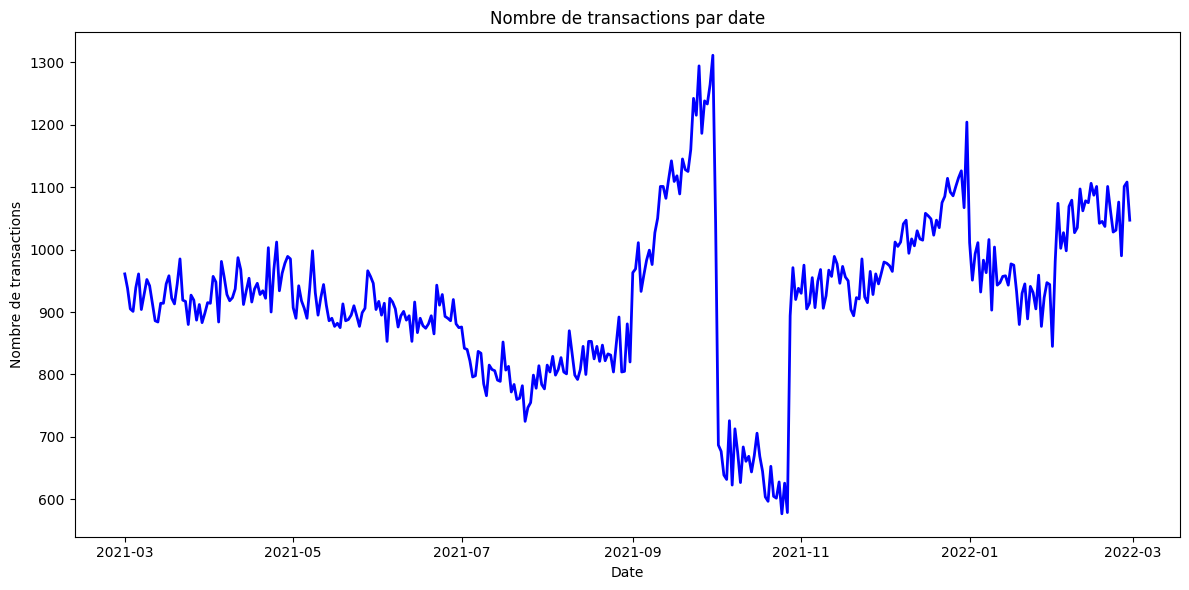

In [32]:
import matplotlib.pyplot as plt

transactions['date_converted'] = pd.to_datetime(transactions['date'], errors='coerce')

data_filtered = transactions.dropna(subset=['date_converted'])

data_filtered['just_date'] = data_filtered['date_converted'].dt.date

transactions_per_date_filtered = data_filtered.groupby('just_date').size()

plt.figure(figsize=(12, 6))
transactions_per_date_filtered.plot(kind='line', color='blue', linewidth=2)
plt.title('Nombre de transactions par date')
plt.xlabel('Date')
plt.ylabel('Nombre de transactions')
plt.tight_layout()
plt.show()


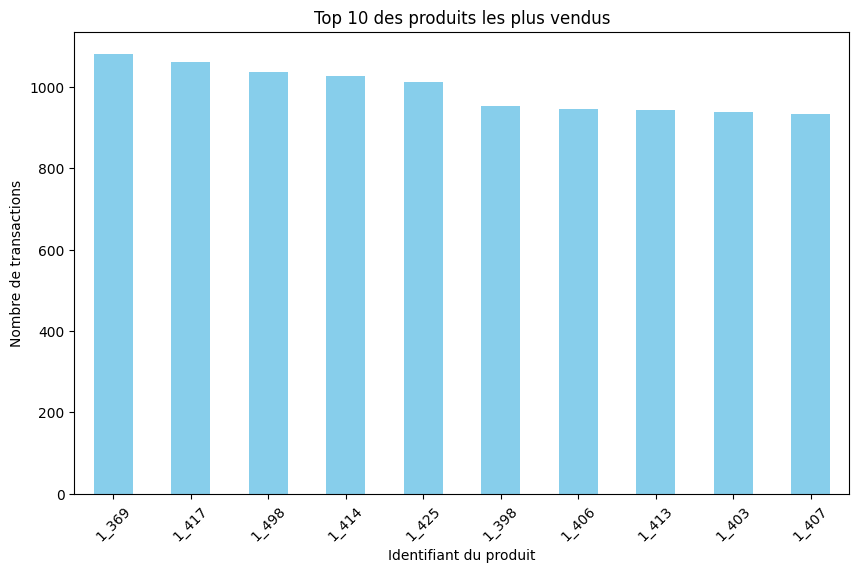

id_prod
1_369    1081
1_417    1062
1_498    1036
1_414    1027
1_425    1013
1_398     952
1_406     946
1_413     944
1_403     939
1_407     933
Name: count, dtype: int64

In [18]:
products_sold = data_filtered['id_prod'].value_counts().head(10)

plt.figure(figsize=(10, 6))
products_sold.plot(kind='bar', color='skyblue')
plt.title('Top 10 des produits les plus vendus')
plt.xlabel('Identifiant du produit')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=45)
plt.show()

products_sold


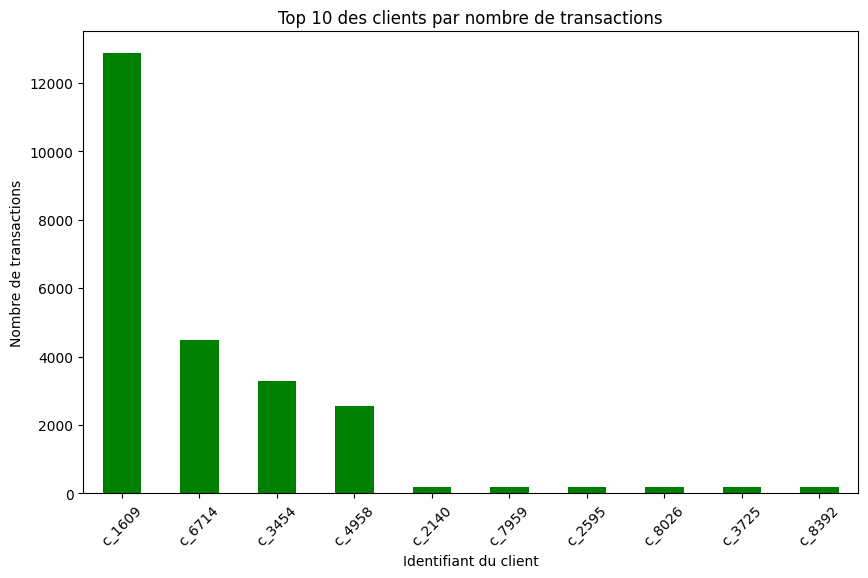

client_id
c_1609    12855
c_6714     4473
c_3454     3275
c_4958     2562
c_2140      195
c_7959      195
c_2595      193
c_8026      193
c_3725      190
c_8392      189
Name: count, dtype: int64

In [19]:
transactions_per_client = data_filtered['client_id'].value_counts().head(10)

plt.figure(figsize=(10, 6))
transactions_per_client.plot(kind='bar', color='green')
plt.title('Top 10 des clients par nombre de transactions')
plt.xlabel('Identifiant du client')
plt.ylabel('Nombre de transactions')
plt.xticks(rotation=45)
plt.show()

transactions_per_client


In [23]:
missing_values = data_filtered.isnull().sum()

missing_values


id_prod           0
date              0
session_id        0
client_id         0
date_converted    0
just_date         0
dtype: int64

In [41]:
# Jointure entre transactions_df et products_df sur id_prod
transactions_products_df = pd.merge(transactions_df.dropna(), products, on='id_prod', how='left')

# Jointure du résultat avec customers_df sur client_id
full_data_df = pd.merge(transactions_products_df, customers, on='client_id', how='left')

# Vérification des premières lignes pour s'assurer que la jointure a bien fonctionné
full_data_df


,id_prod,date,session_id,client_id,price,categ,sex,birth,sex
0,0_1483,2021-04-10 18:37:28.723910,s_18746,c_4450,4.99,0.0,f,1977,f
1,2_226,2022-02-03 01:55:53.276402,s_159142,c_277,65.75,2.0,f,2000,f
2,1_374,2021-09-23 15:13:46.938559,s_94290,c_4270,10.71,1.0,f,1979,f
3,0_2186,2021-10-17 03:27:18.783634,s_105936,c_4597,4.20,0.0,m,1963,f
4,0_1351,2021-07-17 20:34:25.800563,s_63642,c_1242,8.99,0.0,f,1980,f
...,...,...,...,...,...,...,...,...,...
337011,1_671,2021-05-28 12:35:46.214839,s_40720,c_3454,31.99,1.0,m,1969,f
337012,0_759,2021-06-19 00:19:23.917703,s_50568,c_6268,22.99,0.0,m,1991,f
337013,0_1256,2021-03-16 17:31:59.442007,s_7219,c_4137,11.03,0.0,f,1968,f
337014,2_227,2021-10-30 16:50:15.997750,s_112349,c_5,50.99,2.0,f,1994,f


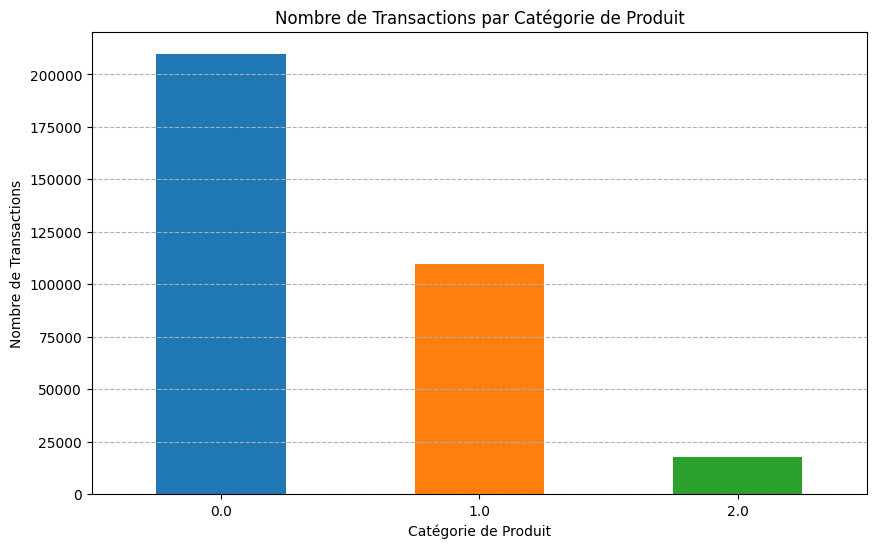

In [45]:
# Calcul du nombre de transactions par catégorie
transactions_by_categ = full_data_df['categ'].value_counts().sort_index()

# Création d'un barplot pour visualiser le nombre de transactions par catégorie
plt.figure(figsize=(10, 6))
transactions_by_categ.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Nombre de Transactions par Catégorie de Produit')
plt.xlabel('Catégorie de Produit')
plt.ylabel('Nombre de Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()
